In [2]:
# Import libraries and load dataset
import pandas as pd
df = pd.read_csv("Ecom UK data.csv", encoding="ISO-8859-1")

# Data Inspection

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Cleaning 1: negative Quantity, negative UnitPrice, and cancelled orders

In [8]:
# Check for negative quantities
df[df["Quantity"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


In [9]:
# Check for cancelled orders (InvoiceNo starting with 'C')
df[df["InvoiceNo"].astype(str).str.startswith("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


In [10]:
# Check how many negative quantity orders are cancelled and how many are not
negative_qty = df[df["Quantity"] < 0]
negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts()


InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [11]:
# Inspect abnormal negative quantity rows without 'C' in InvoiceNo
negative_qty[
    ~negative_qty["InvoiceNo"].astype(str).str.startswith("C")
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,12/1/10 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,12/2/10 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,12/3/10 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,12/3/10 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,12/3/10 15:30,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12/7/11 18:36,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,12/7/11 18:38,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,12/7/11 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/11 9:56,0.0,NaN,United Kingdom


In [12]:
# Create a clean dataset by removing rows with negative Quantity, negative UnitPrice, and cancelled orders
df_raw = df.copy()

df_clean = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

In [13]:
# Compare the shape of the original and cleaned datasets
df.shape
df_clean.shape

(530104, 8)

In [14]:
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,530104.000000,530104.000000,397884.000000
mean,10.542037,3.907625,15294.423453
std,155.524124,35.915681,1713.141560
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


# Data Cleaning 2: Outlier Investigation

In [15]:
# Inspect largest quantity rows
df_clean.sort_values(by="Quantity", ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/11 9:15,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/11 10:01,1.04,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,10/27/11 12:26,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,5/27/11 10:52,0.72,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2/22/11 10:43,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,7/19/11 17:04,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,1/11/11 12:55,2.10,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,4/18/11 13:20,2.10,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,11/2/11 11:24,0.32,16308.0,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,12/2/10 17:38,0.18,16754.0,United Kingdom


In [16]:
# Inspect highest unit price rows
df_clean.sort_values(by="UnitPrice", ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,12/7/10 15:08,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,8/12/11 14:50,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,5/3/11 13:46,8142.75,16029.0,United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,8/11/11 10:14,4505.17,NaN,United Kingdom
268028,560373,M,Manual,1,7/18/11 12:30,4287.63,NaN,United Kingdom
422351,573077,M,Manual,1,10/27/11 14:13,4161.06,12536.0,France
422376,573080,M,Manual,1,10/27/11 14:20,4161.06,12536.0,France
406406,571751,M,Manual,1,10/19/11 11:18,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,10/3/11 16:44,3155.95,15502.0,United Kingdom
347948,567353,M,Manual,1,9/19/11 16:14,2653.95,NaN,Hong Kong


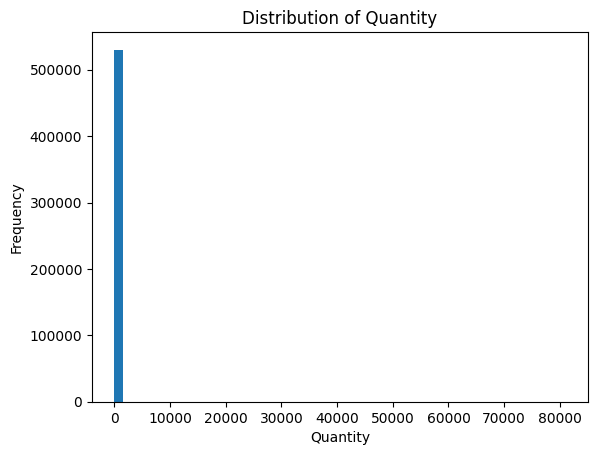

In [17]:
# visualize the distribution of Quantity
import matplotlib.pyplot as plt

plt.hist(df_clean["Quantity"], bins=50)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.show()

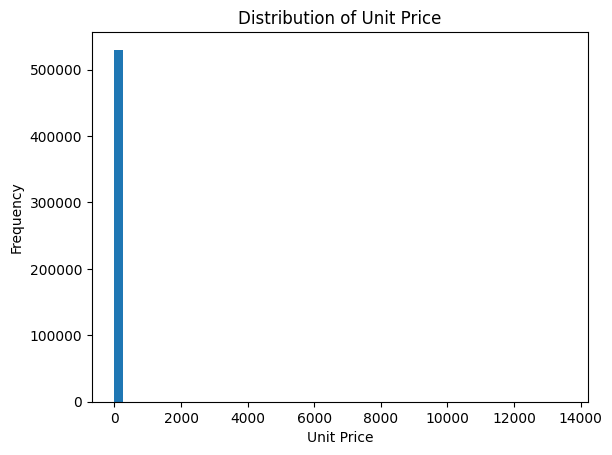

In [18]:
# visualize the distribution of UnitPrice
plt.hist(df_clean["UnitPrice"], bins=50)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price")
plt.show()

In [19]:
# Inspect rows with very high Quantity (e.g., >= 70,000)
df_clean[df_clean["Quantity"] >= 70000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/11 10:01,1.04,12346.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,12/9/11 9:15,2.08,16446.0,United Kingdom


In [20]:
non_product_codes = ["AMAZONFEE", "B", "POST", "DOT", "M"]

df_clean2 = df_clean[
    ~df_clean["StockCode"].isin(non_product_codes)
].copy()

In [21]:
df_clean2 = df_clean2[df_clean2["Quantity"] < 70000].copy()

In [22]:
df_clean2.describe()

,Quantity,UnitPrice,CustomerID
count,527946.000000,527946.000000,396483.000000
mean,10.270147,3.279264,15301.441479
std,37.727006,4.449442,1709.755409
min,1.000000,0.001000,12347.000000
25%,1.000000,1.250000,13975.000000
50%,3.000000,2.080000,15159.000000
75%,11.000000,4.130000,16801.000000
max,4800.000000,649.500000,18287.000000


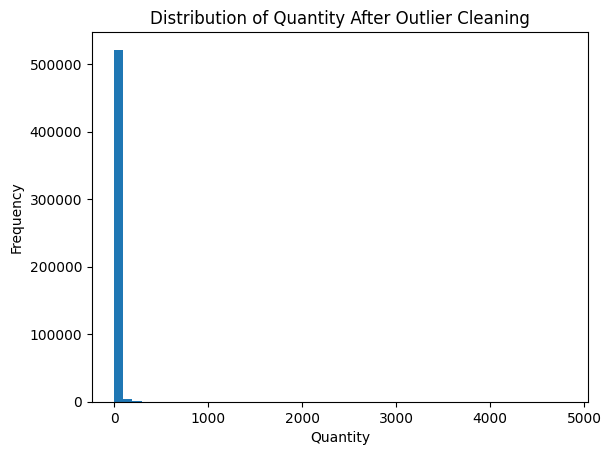

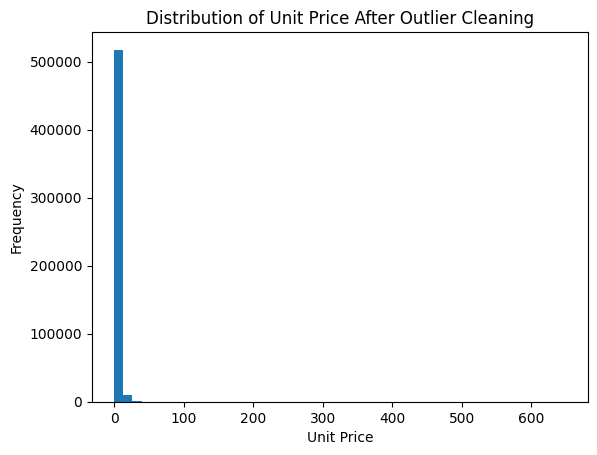

In [23]:
plt.hist(df_clean2["Quantity"], bins=50)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity After Outlier Cleaning")
plt.show()

plt.hist(df_clean2["UnitPrice"], bins=50)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price After Outlier Cleaning")
plt.show()

The distributions of Quantity and UnitPrice remained heavily right-skewed even after outlier cleaning, indicating that most ecommerce transactions involve small purchase quantities and low-priced items, while a small number of transactions contain very large values.

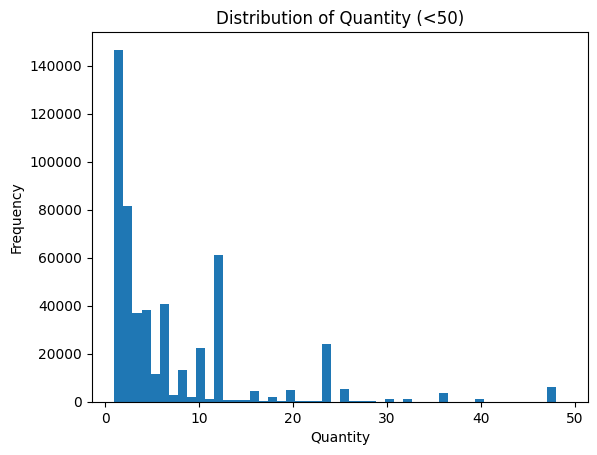

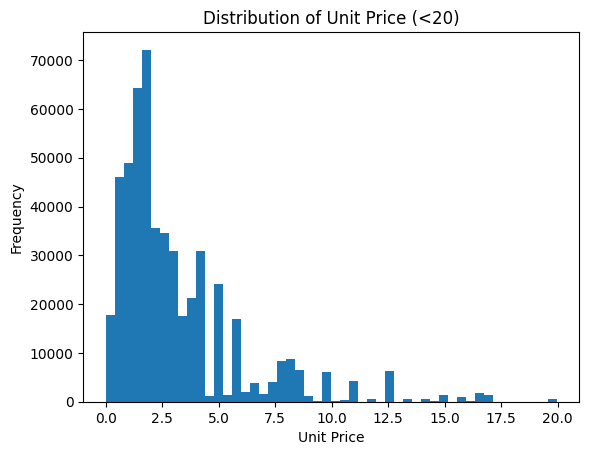

In [24]:
# Zoom into the common range
plt.hist(df_clean2[df_clean2["Quantity"] < 50]["Quantity"], bins=50)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity (<50)")
plt.show()

plt.hist(df_clean2[df_clean2["UnitPrice"] < 20]["UnitPrice"], bins=50)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price (<20)")
plt.show()

In [25]:
df_final = df_clean2.copy()

In [26]:
# Check missing values
df_final.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131463
Country             0
dtype: int64

In [27]:
# Original full dataset
df_raw = df.copy()
# for clean dataset
df_final = df_clean2.copy()

In [28]:
# for Customer Analysis
df_customer = df_final.dropna(subset=["CustomerID"]).copy()


df_customer['CustomerID'] = df_customer['CustomerID'].astype(int).astype(str)

In [29]:
# for Returns/cancelled orders analysis
df_returns = df_raw[
    (df_raw["Quantity"] < 0) |
    (df_raw["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

# Calculate return value
df_returns["ReturnValue"] = abs(df_returns["Quantity"] * df_returns["UnitPrice"])

## Exploratory Data Analysis
## 1. Sales Performance Analysis

In [30]:
# Prepare data for sales analysis
# Make sure InvoiceDate is in datetime format
df_final["InvoiceDate"] = pd.to_datetime(df_final["InvoiceDate"])

# Create Sales column
df_final["Sales"] = df_final["Quantity"] * df_final["UnitPrice"]

# Create time-related columns
df_final["Year"] = df_final["InvoiceDate"].dt.year
df_final["Month"] = df_final["InvoiceDate"].dt.month
df_final["YearMonth"] = df_final["InvoiceDate"].dt.to_period("M")
df_final["Hour"] = df_final["InvoiceDate"].dt.hour
df_final["DayOfWeek"] = df_final["InvoiceDate"].dt.day_name()

/var/folders/q5/5vwr4ldd30vgm4b8qpnrkcym0000gn/T/ipykernel_1530/1912635317.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final["InvoiceDate"] = pd.to_datetime(df_final["InvoiceDate"])


In [31]:
df_final[["InvoiceDate", "Quantity", "UnitPrice", "Sales", "YearMonth", "Hour", "DayOfWeek"]].head()

,InvoiceDate,Quantity,UnitPrice,Sales,YearMonth,Hour,DayOfWeek
0,2010-12-01 08:26:00,6,2.55,15.30,2010-12,8,Wednesday
1,2010-12-01 08:26:00,6,3.39,20.34,2010-12,8,Wednesday
2,2010-12-01 08:26:00,8,2.75,22.00,2010-12,8,Wednesday
3,2010-12-01 08:26:00,6,3.39,20.34,2010-12,8,Wednesday
4,2010-12-01 08:26:00,6,3.39,20.34,2010-12,8,Wednesday


In [32]:
# Q1. What is the total revenue?

total_revenue = df_final["Sales"].sum()
print("Total Revenue: £{:,.2f}".format(total_revenue))

Total Revenue: £10,033,747.27


In [33]:
# Q2. How does monthly revenue change over time?
monthly_revenue = df_final.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_revenue

,YearMonth,Sales
0,2010-12,778625.910
1,2011-01,595023.810
2,2011-02,509167.870
3,2011-03,692015.940
4,2011-04,516754.791
5,2011-05,741726.740
6,2011-06,739426.880
7,2011-07,689947.741
8,2011-08,726005.160
9,2011-09,1031430.362


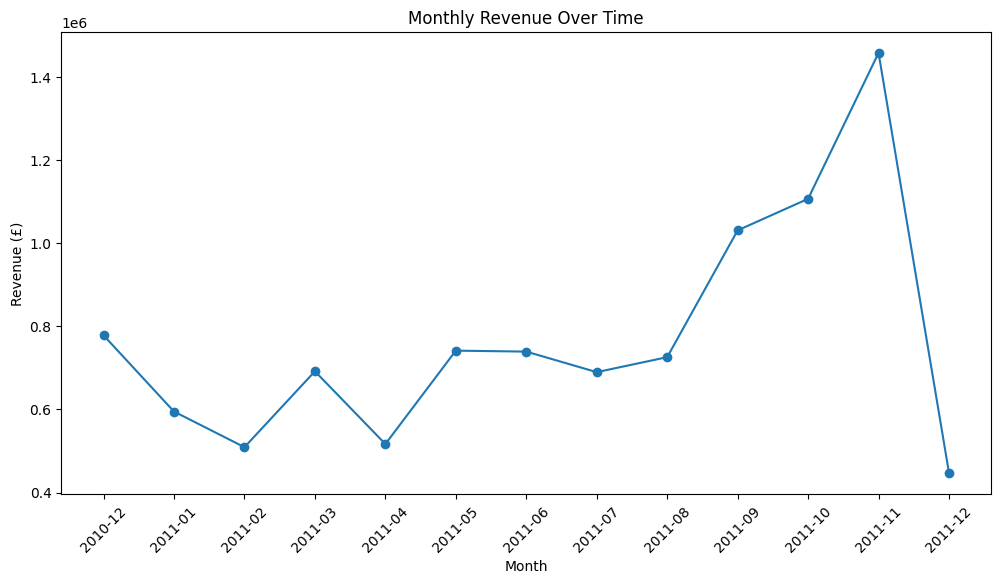

In [34]:
# Convert YearMonth to string for better plotting
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

# Visualize monthly revenue over time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Sales"], marker="o")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.title("Monthly Revenue Over Time")
plt.xticks(rotation=45)
plt.show()

Remark: 
Monthly revenue: November is unusually peak. December is quite low as the data is for only until 9th Dec.
Needs to enquire for the lowest sales months, Feb & April.

In [35]:
# Q3. Which months have the highest sales?
highest_sales_months = monthly_revenue.sort_values(by="Sales", ascending=False)
highest_sales_months.head(10)

# Top 3 months with highest sales: Sep, Oct, Nov 2011

,YearMonth,Sales
11,2011-11,1458925.530
10,2011-10,1107449.540
9,2011-09,1031430.362
0,2010-12,778625.910
5,2011-05,741726.740
6,2011-06,739426.880
8,2011-08,726005.160
3,2011-03,692015.940
7,2011-07,689947.741
1,2011-01,595023.810


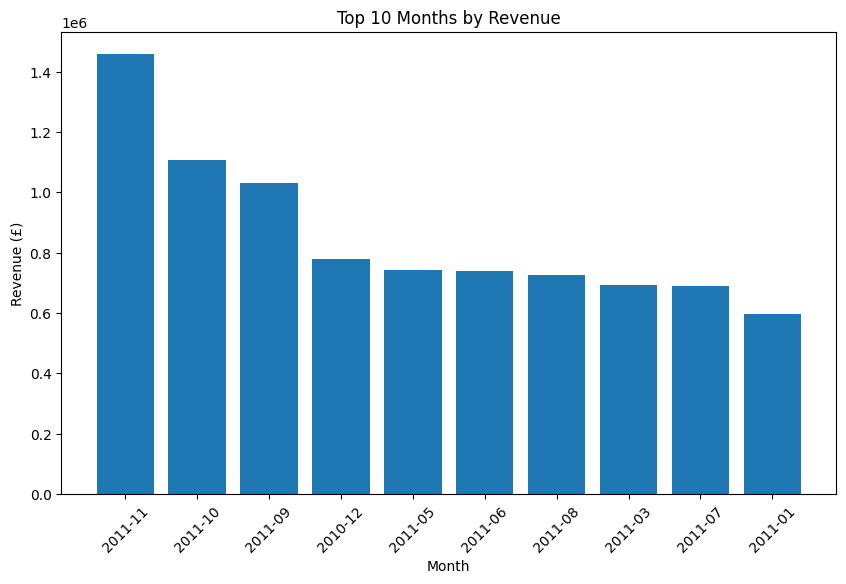

In [36]:
# Visualize top 10 months with highest sales
top_months = highest_sales_months.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_months["YearMonth"], top_months["Sales"])
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.title("Top 10 Months by Revenue")
plt.xticks(rotation=45)
plt.show()

In [37]:
# Q4. What is the average order value? (How much revenue does each order generate on average?)
# Calculate total sales for each order/Invoice
order_value = df_final.groupby("InvoiceNo")["Sales"].sum().reset_index()
order_value.describe() # Optional: Check distribution of order values
order_value.head()

,InvoiceNo,Sales
0,536365,139.12
1,536366,22.20
2,536367,278.73
3,536368,70.05
4,536369,17.85


In [38]:
average_order_value = order_value["Sales"].mean() # Calculate average order value
print("Average Order Value: £{:,.2f}".format(average_order_value))

Average Order Value: £507.09


In [39]:
# Q5. Which time period has the most sales?
# Sales by hour
sales_by_hour = df_final.groupby("Hour")["Sales"].sum().reset_index()
sales_by_hour.sort_values(by="Sales", ascending=False)

,Hour,Sales
6,12,1418960.590
4,10,1327250.731
9,15,1277053.070
7,13,1225947.170
5,11,1201008.700
8,14,1124518.191
3,9,788203.391
10,16,710568.410
11,17,441919.451
2,8,279865.520


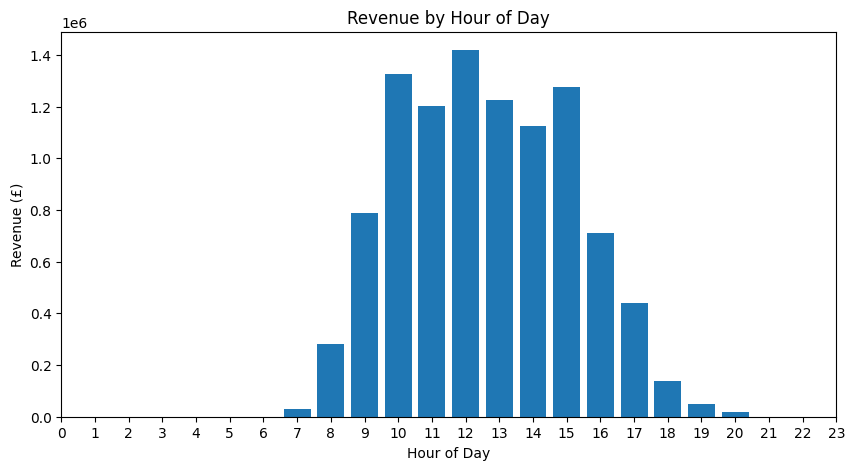

In [40]:
# Visualize sales by hour
plt.figure(figsize=(10, 5))
plt.bar(sales_by_hour["Hour"], sales_by_hour["Sales"])
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")
plt.title("Revenue by Hour of Day")
plt.xticks(range(0, 24))
plt.show()

In [41]:
# Sales by Day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day = df_final.groupby("DayOfWeek")["Sales"].sum().reindex(day_order).reset_index()
sales_by_day.sort_values(by="Sales", ascending=False)

# Remark: No sales on Saturday

,DayOfWeek,Sales
3,Thursday,2137615.270
1,Tuesday,2012071.371
2,Wednesday,1787752.360
0,Monday,1687757.531
4,Friday,1602702.411
6,Sunday,805848.331
5,Saturday,NaN


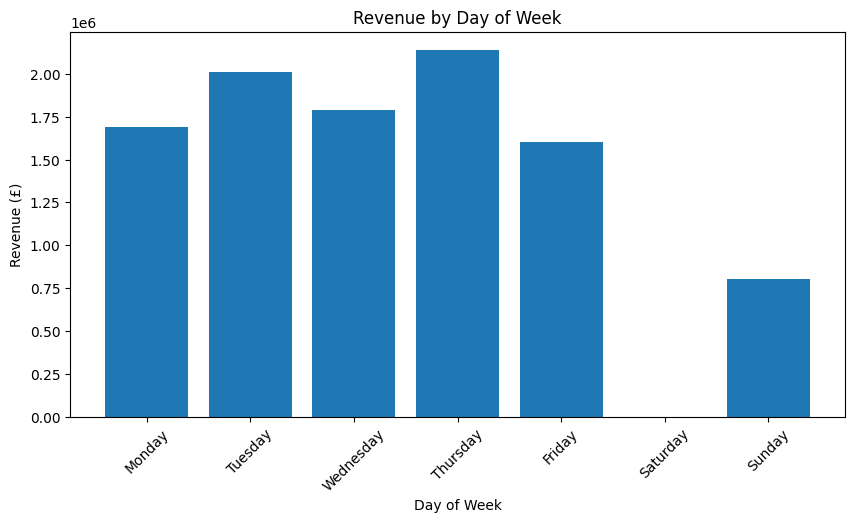

In [42]:
# Visualize sales by day of week
plt.figure(figsize=(10, 5))
plt.bar(sales_by_day["DayOfWeek"], sales_by_day["Sales"])
plt.xlabel("Day of Week")
plt.ylabel("Revenue (£)")
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
plt.show()

In [43]:
# Sales by Month name (general monthly pattern ignoring year)
df_final["MonthName"] = df_final["InvoiceDate"].dt.month_name()
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

sales_by_month_name = df_final.groupby("MonthName")["Sales"].sum().reindex(month_order).reset_index()
sales_by_month_name.sort_values(by="Sales", ascending=False)

#Remark:the Dec mentioned in the output has to be from Dec 2010 as Dec 2011 has very low sales compared to other months in 2011

,MonthName,Sales
10,November,1458925.530
11,December,1225872.910
9,October,1107449.540
8,September,1031430.362
4,May,741726.740
5,June,739426.880
7,August,726005.160
2,March,692015.940
6,July,689947.741
0,January,595023.810


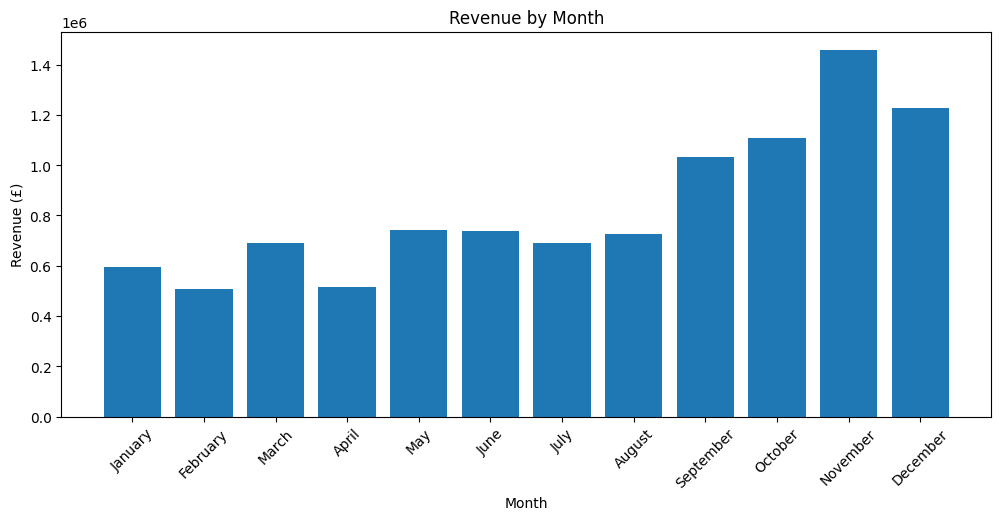

In [44]:
# Visualize sales by month name
plt.figure(figsize=(12, 5))
plt.bar(sales_by_month_name["MonthName"], sales_by_month_name["Sales"])
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.title("Revenue by Month")
plt.xticks(rotation=45)
plt.show()

In [45]:
# Summary table of key sales metrics
total_orders = df_final["InvoiceNo"].nunique()
total_products_sold = df_final["Quantity"].sum()
total_revenue = df_final["Sales"].sum()
average_order_value = order_value["Sales"].mean()

sales_summary_df = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Orders", "Total Quantity Sold", "Average Order Value"],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,.0f}",
        f"{total_products_sold:,.0f}",
        f"£{average_order_value:,.2f}"
    ]
})
sales_summary_df

,Metric,Value
0,Total Revenue,"£10,033,747.27"
1,Total Orders,"19,787"
2,Total Quantity Sold,"5,422,083"
3,Average Order Value,£507.09


### Sales Performance Summary

The sales performance analysis shows that the business generated £10.03 million in revenue from 19,787 orders, with an average order value of £507.09. Monthly revenue increased strongly toward the end of 2011, with November 2011 being the highest-performing month. This suggests a clear seasonal pattern, likely connected to pre-holiday purchasing behavior. Sales were concentrated during weekday business hours, especially between 10:00 and 15:00, with Thursday generating the highest revenue among weekdays. Overall, the business appears to experience strong late-year demand and weekday-centered purchasing activity.


## Product Analysis

In [46]:
# Q6. Which products generate the most revenue?
top_revenue_products = (
    df_final
    .groupby(["StockCode", "Description"], as_index=False)["Sales"]
    .sum()
    .sort_values(by="Sales", ascending=False)
    .head(10)
)

top_revenue_products

,StockCode,Description,Sales
1340,22423,REGENCY CAKESTAND 3 TIER,174484.74
3639,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104340.29
2876,47566,PARTY BUNTING,99504.33
3618,85099B,JUMBO BAG RED RETROSPOT,94340.05
2029,23084,RABBIT NIGHT LIGHT,66964.99
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64952.29
3415,84879,ASSORTED COLOUR BIRD ORNAMENT,59094.93
3058,79321,CHILLI LIGHTS,54117.76
2285,23298,SPOTTY BUNTING,42548.13
1307,22386,JUMBO BAG PINK POLKADOT,42436.24


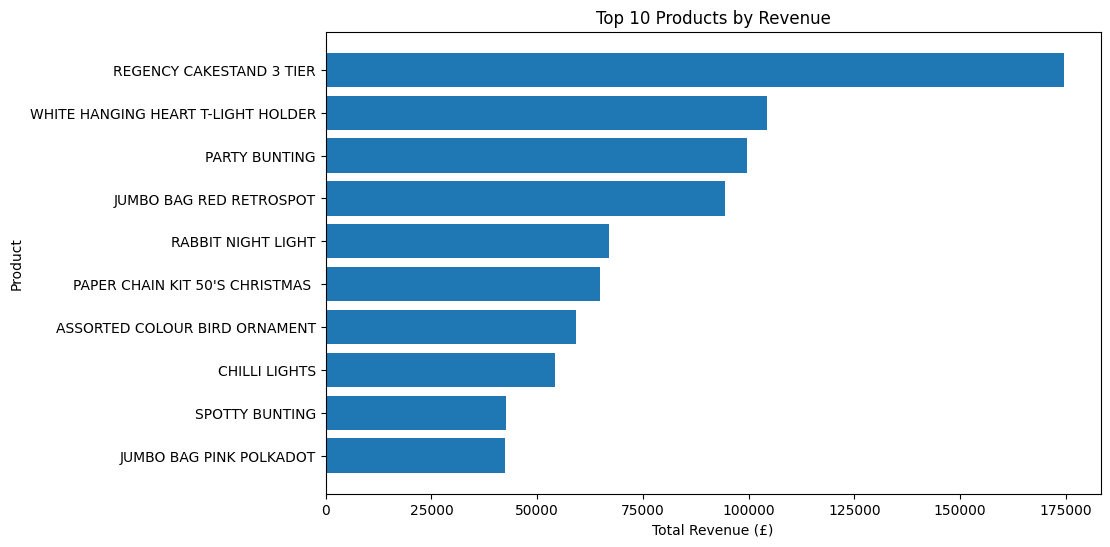

In [47]:
# Visualize top 10 products by revenue
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_revenue_products["Description"], top_revenue_products["Sales"])
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.show()

In [48]:
# Q7. Which products are sold in the highest quantity?
top_quantity_products = (
    df_final
    .groupby(["StockCode", "Description"], as_index=False)["Quantity"]
    .sum()
    .sort_values(by="Quantity", ascending=False)
    .head(10)
)

top_quantity_products

,StockCode,Description,Quantity
3127,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
3618,85099B,JUMBO BAG RED RETROSPOT,48474
3639,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37599
1129,22197,POPCORN HOLDER,36761
3415,84879,ASSORTED COLOUR BIRD ORNAMENT,36461
448,21212,PACK OF 72 RETROSPOT CAKE CASES,36419
2029,23084,RABBIT NIGHT LIGHT,30788
1405,22492,MINI PAINT SET VINTAGE,26633
1528,22616,PACK OF 12 LONDON TISSUES,26135
946,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24854


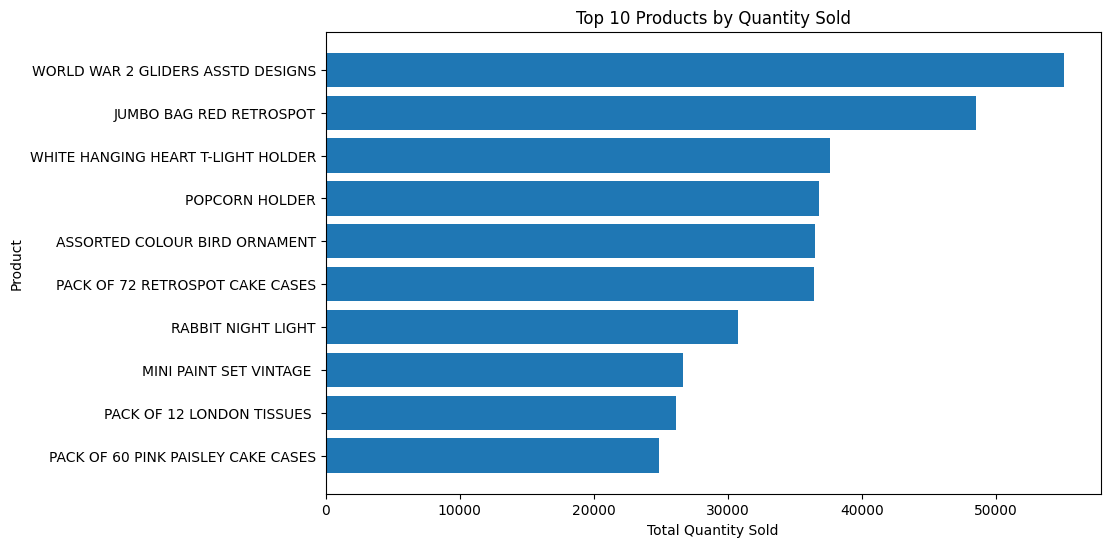

In [49]:
# Visualize top 10 products by quantity sold
plt.figure(figsize=(10, 6))
plt.barh(top_quantity_products["Description"], top_quantity_products["Quantity"])
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Products by Quantity Sold")
plt.gca().invert_yaxis()
plt.show()

# Customer Analysis

In [50]:
# Make sure Sales column exists in df_final
df_final["Sales"] = df_final["Quantity"] * df_final["UnitPrice"]

# Recreate df_customer after creating Sales
df_customer = df_final.dropna(subset=["CustomerID"]).copy()

# Convert CustomerID to string
df_customer["CustomerID"] = df_customer["CustomerID"].astype(str)

# Check
df_customer[["CustomerID", "Quantity", "UnitPrice", "Sales"]].head()

,CustomerID,Quantity,UnitPrice,Sales
0,17850.0,6,2.55,15.30
1,17850.0,6,3.39,20.34
2,17850.0,8,2.75,22.00
3,17850.0,6,3.39,20.34
4,17850.0,6,3.39,20.34


In [51]:
# Customer Analysis
# Dataset used: df_customer

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure InvoiceDate is datetime
df_customer["InvoiceDate"] = pd.to_datetime(df_customer["InvoiceDate"])

In [52]:
# Q8. How many unique customers does the business have?
unique_customers = df_customer["CustomerID"].nunique()

print(f"Number of unique customers: {unique_customers:,}")

Number of unique customers: 4,334


In [53]:
# Q9. Who are the top 10 customers by revenue?

# Create Sales column
df_final["Sales"] = df_final["Quantity"] * df_final["UnitPrice"]

top_customers_revenue = (
    df_customer
    .groupby("CustomerID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_10_customers = top_customers_revenue.head(10)

top_10_customers

,CustomerID,Sales
0,14646.0,279138.02
1,18102.0,259657.30
2,17450.0,194550.79
3,14911.0,140450.72
4,12415.0,124564.53
5,14156.0,117379.63
6,17511.0,91062.38
7,16029.0,72882.09
8,16684.0,66653.56
9,13694.0,65039.62


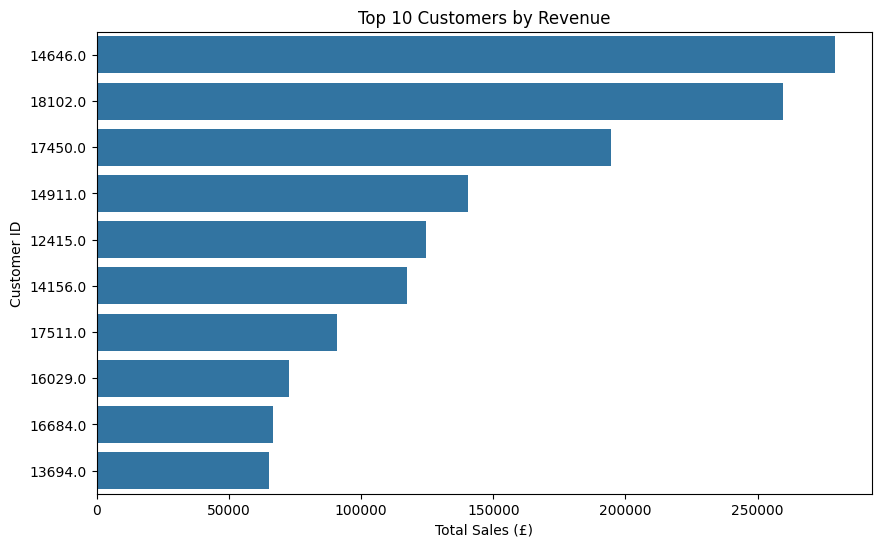

In [54]:
# Visualize top 10 customers by revenue
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_customers,
    x="Sales",
    y="CustomerID"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Sales (£)")
plt.ylabel("Customer ID")
plt.show()

In [55]:
# Q10. How often do customers purchase?
# We count how many unique invoices each customer has.(Purchase frequency)

purchase_frequency = (
    df_customer
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
purchase_frequency.columns = ["CustomerID", "Number_of_Orders"]
purchase_frequency.head(10)


,CustomerID,Number_of_Orders
0,12748.0,206
1,14911.0,199
2,17841.0,124
3,13089.0,97
4,14606.0,91
5,15311.0,91
6,12971.0,86
7,14646.0,72
8,16029.0,62
9,13408.0,62


In [56]:
# Summarystatistics of purchase frequency
purchase_frequency["Number_of_Orders"].describe()

count    4334.000000
mean        4.248731
std         7.646830
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: Number_of_Orders, dtype: float64

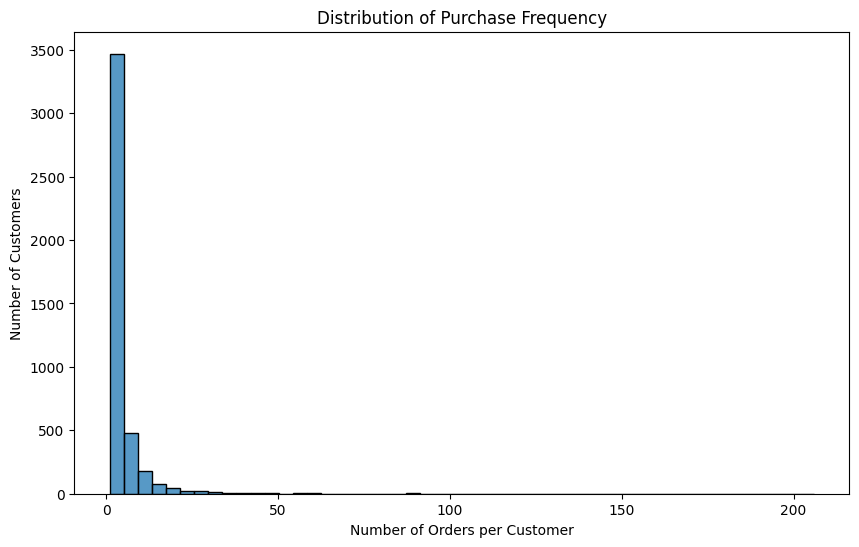

In [57]:
# Visualize distribution of purchase frequency
plt.figure(figsize=(10, 6))

sns.histplot(
    purchase_frequency["Number_of_Orders"],
    bins=50
)
plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.show()

#Remark: As e-commerce data is usually skewed, many customers may purchase only once, while a smaller group purchases frequently.

In [58]:
# Optional: No. of one-time customers (only 1 order)
one_time_customers = purchase_frequency[purchase_frequency["Number_of_Orders"] == 1].shape[0]

print(f"Number of one-time customers: {one_time_customers:,}")
print(f"Percentage of one-time customers: {one_time_customers / unique_customers * 100:.2f}%")

Number of one-time customers: 1,505
Percentage of one-time customers: 34.73%


In [59]:
# Q11. Can we segment customers based on behavior?
# Customer level summary table

customer_summary = (
    df_customer
    .groupby("CustomerID")
    .agg(
        Total_Sales=("Sales", "sum"),
        Number_of_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_summary["Avg_Order_Value"] = (
    customer_summary["Total_Sales"] / customer_summary["Number_of_Orders"]
)

customer_summary["Customer_Lifetime_Days"] = (
    customer_summary["Last_Purchase"] - customer_summary["First_Purchase"]
).dt.days

customer_summary.head()

,CustomerID,Total_Sales,Number_of_Orders,Total_Quantity,First_Purchase,Last_Purchase,Avg_Order_Value,Customer_Lifetime_Days
0,12347.0,4310.00,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365
1,12348.0,1437.24,4,2332,2010-12-16 19:09:00,2011-09-25 13:13:00,359.310000,282
2,12349.0,1457.55,1,630,2011-11-21 09:51:00,2011-11-21 09:51:00,1457.550000,0
3,12350.0,294.40,1,196,2011-02-02 16:01:00,2011-02-02 16:01:00,294.400000,0
4,12352.0,1385.74,7,526,2011-02-16 12:33:00,2011-11-03 14:37:00,197.962857,260


In [60]:
# Customer segmentation based on Total Sales and No.of Orders (Purchase Frequency)

sales_75 = customer_summary["Total_Sales"].quantile(0.75)
orders_75 = customer_summary["Number_of_Orders"].quantile(0.75)

def segment_customer(row):
    if row["Total_Sales"] >= sales_75 and row["Number_of_Orders"] >= orders_75:
        return "High-Value Loyal Customers"
    elif row["Total_Sales"] >= sales_75:
        return "High-Spending Customers"
    elif row["Number_of_Orders"] >= orders_75:
        return "Frequent Customers"
    elif row["Number_of_Orders"] == 1:
        return "One-Time Customers"
    else:
        return "Regular Customers"

customer_summary["Customer_Segment"] = customer_summary.apply(segment_customer, axis=1)

customer_summary.head()

,CustomerID,Total_Sales,Number_of_Orders,Total_Quantity,First_Purchase,Last_Purchase,Avg_Order_Value,Customer_Lifetime_Days,Customer_Segment
0,12347.0,4310.00,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365,High-Value Loyal Customers
1,12348.0,1437.24,4,2332,2010-12-16 19:09:00,2011-09-25 13:13:00,359.310000,282,Regular Customers
2,12349.0,1457.55,1,630,2011-11-21 09:51:00,2011-11-21 09:51:00,1457.550000,0,One-Time Customers
3,12350.0,294.40,1,196,2011-02-02 16:01:00,2011-02-02 16:01:00,294.400000,0,One-Time Customers
4,12352.0,1385.74,7,526,2011-02-16 12:33:00,2011-11-03 14:37:00,197.962857,260,Frequent Customers


* High-Value Loyal Customers: These customers spend a lot and buy often.They are probably the most valuable customers. The business should retain them with loyalty programs, personalized offers, or early access promotions.
* High-Spending Customers: These customers spend a lot, but they may not order very often.They may make large purchases occasionally. The business could encourage them to purchase more frequently.
* Frequent Customers: These customers buy often, but their total spending may not be among the highest.They are engaged customers. The business could encourage upselling or cross-selling to increase their order value.
* One-Time Customers: These customers purchased only once. They are important for reactivation campaigns. The business could send follow-up offers or reminders to encourage a second purchase.
* Regular Customers: These customers do not fall into the high-sales, high-frequency, or one-time categories.They are normal customers with moderate activity.


In [61]:
# Number of customers by segment
segment_counts = (
    customer_summary["Customer_Segment"]
    .value_counts()
    .reset_index()
)
segment_counts.columns = ["Customer_Segment", "Number_of_Customers"]
segment_counts

,Customer_Segment,Number_of_Customers
0,Regular Customers,1503
1,One-Time Customers,1475
2,High-Value Loyal Customers,830
3,Frequent Customers,272
4,High-Spending Customers,254


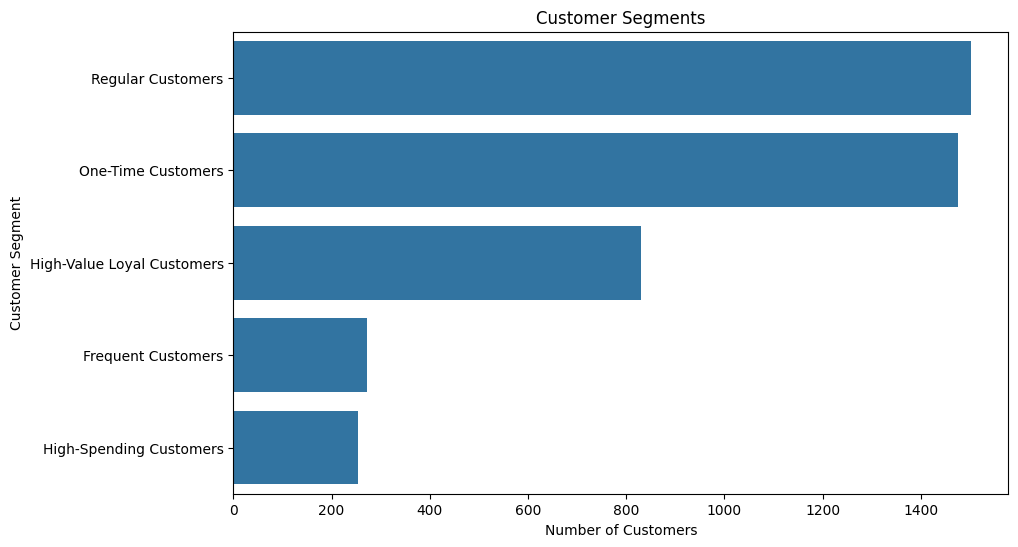

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_counts,
    x="Number_of_Customers",
    y="Customer_Segment"
)
plt.title("Customer Segments")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.show()

In [63]:
# How much revenue does each customer segment contribute?
# The largest segment by number of customers may not always be the largest segment by revenue.

segment_revenue = (
    customer_summary
    .groupby("Customer_Segment")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
segment_revenue

,Customer_Segment,Total_Sales
0,High-Value Loyal Customers,5903714.090
1,Regular Customers,1060646.252
2,High-Spending Customers,785929.251
3,One-Time Customers,463807.481
4,Frequent Customers,308167.380


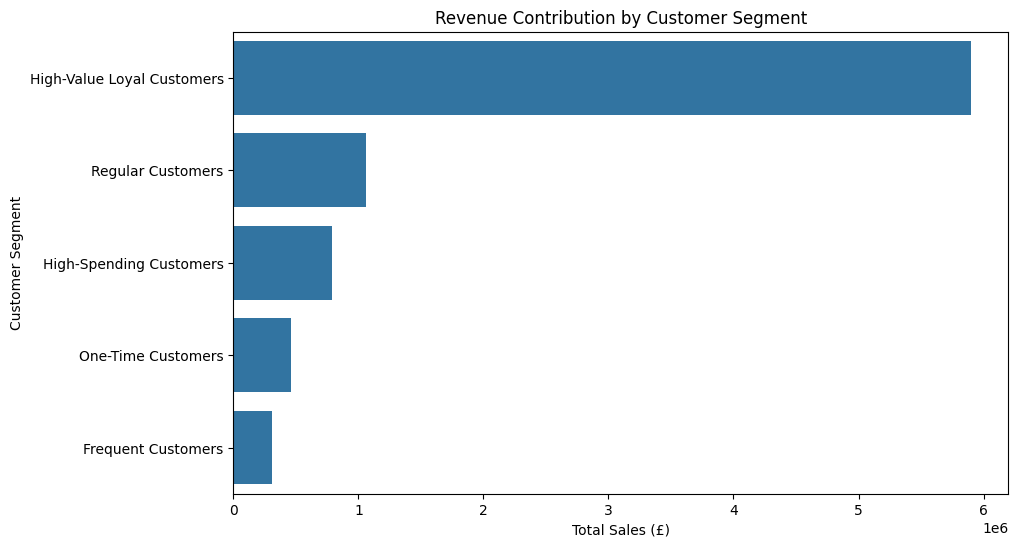

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_revenue,
    x="Total_Sales",
    y="Customer_Segment"
)
plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Sales (£)")
plt.ylabel("Customer Segment")
plt.show()

## Summary Customer Analysis

Overall, the customer analysis shows that revenue is highly concentrated among repeat and high-value customers. While the business has more than **4,300 unique customers**, many customers purchase only once or twice. The most valuable group is the **High-Value Loyal Customers** segment, which generates the majority of sales despite being smaller than the regular and one-time customer groups.

From a business perspective, this suggests three possible strategies:

1. **Retain high-value loyal customers** through loyalty programs, personalized offers, and priority service.
2. **Convert one-time customers into repeat buyers** through follow-up campaigns, discount codes, or email marketing.
3. **Increase spending among frequent customers** by using product recommendations, bundles, or upselling strategies.

For a portfolio, this analysis is useful because it shows not only who the customers are, but also how customer behavior connects to revenue performance.


## Country Analysis

In [65]:
# Q12. Which countries generate the most revenue?
# Total sales by country
country_sales = (
    df_final.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display top 10 countries by sales
top_country_sales = country_sales.head(10)
top_country_sales["Sales"] = top_country_sales["Sales"].round(2)

print("Top 10 Countries by Sales")
print(top_country_sales)

Top 10 Countries by Sales
          Country       Sales
0  United Kingdom  8504299.87
1     Netherlands   283889.34
2            EIRE   276404.30
3         Germany   205569.89
4          France   184768.74
5       Australia   138171.31
6           Spain    55725.11
7     Switzerland    53087.90
8           Japan    37416.37
9         Belgium    36927.34


/var/folders/q5/5vwr4ldd30vgm4b8qpnrkcym0000gn/T/ipykernel_1530/2544841082.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_country_sales["Sales"] = top_country_sales["Sales"].round(2)


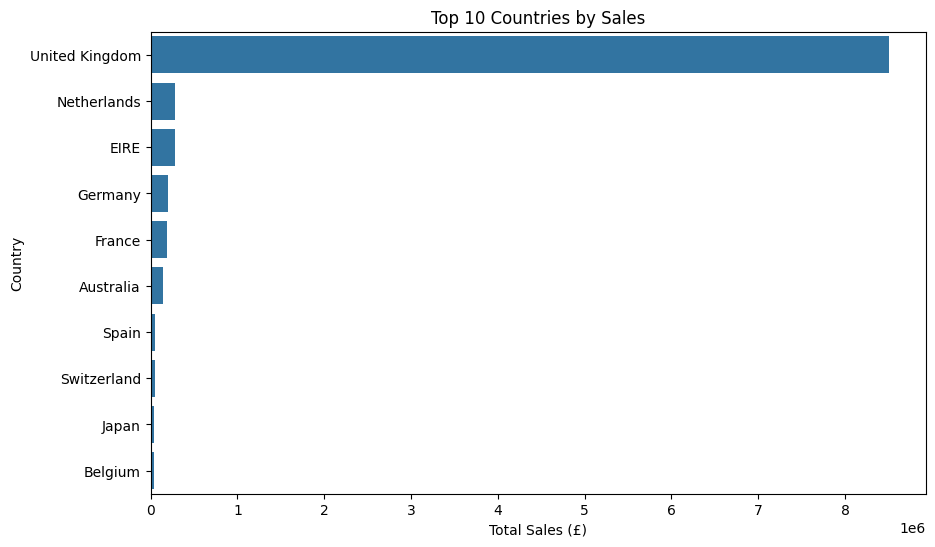

In [66]:
# Bar chart of top 10 countries by sales
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_country_sales,
    x="Sales",
    y="Country"
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales (£)")
plt.ylabel("Country")
plt.show()

In [67]:
# Q13. Is the business highly dependent on the United Kingdom?
# Total sales overall
total_sales = df_final["Sales"].sum()

# UK sales
uk_sales = df_final[df_final["Country"] == "United Kingdom"]["Sales"].sum()

# UK sales percentage
uk_sales_percentage = (uk_sales / total_sales) * 100

print(f"Total Sales: £{total_sales:,.2f}")
print(f"United Kingdom Sales: £{uk_sales:,.2f}")
print(f"UK Share of Total Sales: {uk_sales_percentage:.2f}%")

Total Sales: £10,033,747.27
United Kingdom Sales: £8,504,299.87
UK Share of Total Sales: 84.76%


In [68]:
# Create a new column to classify UK and non-UK sales
df_final["Market"] = df_final["Country"].apply(
    lambda x: "United Kingdom" if x == "United Kingdom" else "Other Countries"
)

uk_dependency = (
    df_final.groupby("Market")["Sales"]
    .sum()
    .reset_index()
)

uk_dependency["Sales_Percentage"] = (
    uk_dependency["Sales"] / uk_dependency["Sales"].sum()
) * 100

uk_dependency

,Market,Sales,Sales_Percentage
0,Other Countries,1529447.400,15.243033
1,United Kingdom,8504299.874,84.756967


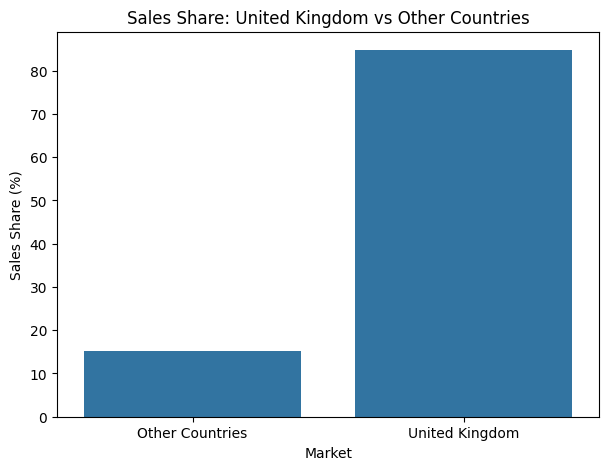

In [69]:
# Bar Chart to visualize UK vs Other Countries sales share
plt.figure(figsize=(7, 5))

sns.barplot(
    data=uk_dependency,
    x="Market",
    y="Sales_Percentage"
)

plt.title("Sales Share: United Kingdom vs Other Countries")
plt.xlabel("Market")
plt.ylabel("Sales Share (%)")
plt.show()

In [70]:
# Q14. Which countries have high average order values?
# Average Order Value = Total Sales / Number of Orders

# First calculate sales per order by country
country_order_sales = (
    df_final.groupby(["Country", "InvoiceNo"])["Sales"]
    .sum()
    .reset_index()
)

# Then calculate average order value by country
country_aov = (
    country_order_sales.groupby("Country")
    .agg(
        Total_Sales=("Sales", "sum"),
        Number_of_Orders=("InvoiceNo", "nunique"),
        Average_Order_Value=("Sales", "mean")
    )
    .sort_values(by="Average_Order_Value", ascending=False)
    .reset_index()
)

country_aov.head(10)

,Country,Total_Sales,Number_of_Orders,Average_Order_Value
0,Netherlands,283889.34,93,3052.573548
1,Australia,138171.31,56,2467.344821
2,Singapore,9120.39,4,2280.097500
3,Japan,37416.37,19,1969.282632
4,Lebanon,1693.88,1,1693.880000
5,Hong Kong,9952.99,7,1421.855714
6,Brazil,1143.60,1,1143.600000
7,Sweden,36839.33,34,1083.509706
8,Switzerland,53087.90,50,1061.758000
9,Israel,8135.26,8,1016.907500


In [71]:
# Some countries may have very high average order value only because they have 1 or 2 orders. 
# Filter countries with at least 10 orders
country_aov_filtered = country_aov[country_aov["Number_of_Orders"] >= 10]

# Top 10 countries by average order value
top_country_aov = country_aov_filtered.head(10)

top_country_aov

,Country,Total_Sales,Number_of_Orders,Average_Order_Value
0,Netherlands,283889.34,93,3052.573548
1,Australia,138171.31,56,2467.344821
3,Japan,37416.37,19,1969.282632
7,Sweden,36839.33,34,1083.509706
8,Switzerland,53087.90,50,1061.758000
10,Norway,32454.64,32,1014.207500
11,Denmark,18211.34,18,1011.741111
13,EIRE,276404.30,284,973.254577
14,Cyprus,13254.69,14,946.763571
17,Channel Islands,20157.44,25,806.297600


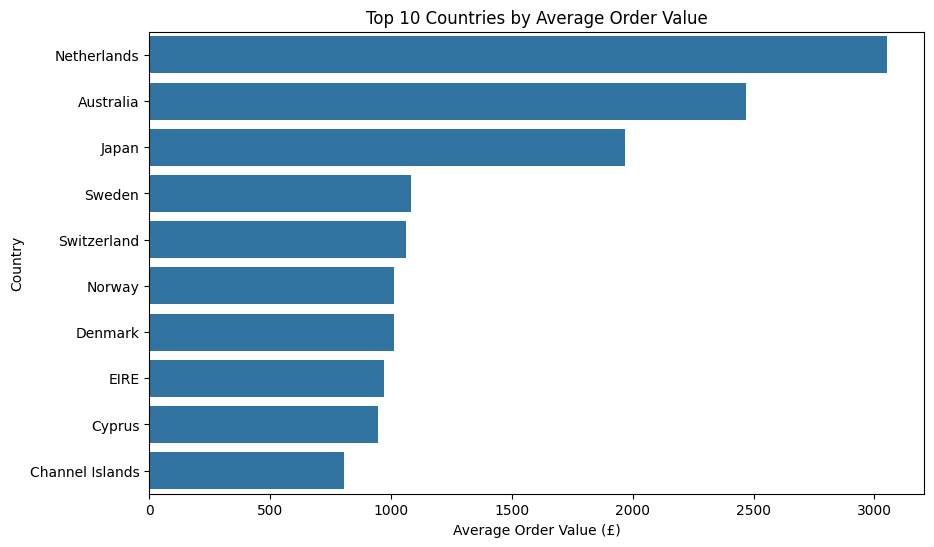

In [72]:
# Bar chart of top 10 countries by average order value
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_country_aov,
    x="Average_Order_Value",
    y="Country"
)

plt.title("Top 10 Countries by Average Order Value")
plt.xlabel("Average Order Value (£)")
plt.ylabel("Country")
plt.show()

# Summary of Country Analysis
Country-level analysis shows that the business is strongly concentrated in the United Kingdom, which accounts for approximately 84.8% of total sales. This indicates that the UK is the company’s core market and main revenue driver. However, this also creates a dependency risk, as the business relies heavily on one geographic market.

International markets contribute a smaller share of total sales, but some countries show much higher average order values. The Netherlands has the highest average order value at around £3,052.57, followed by Australia and Japan. This suggests that while the UK generates revenue through a high volume of orders, some overseas markets generate larger-value orders on average.

Overall, the business appears to be domestically concentrated but has promising international opportunities. Countries such as the Netherlands, Australia, Japan, Switzerland, and EIRE may be valuable markets for further growth because they show strong order values despite lower total sales volumes.

## Returns/ Cancellations Analysis

In [73]:
# Preparation for Returns/cancelled orders analysis (already done in previous stage before EDA starts)
df_returns = df_raw[
    (df_raw["Quantity"] < 0) |
    (df_raw["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

# Calculate return value
df_returns["ReturnValue"] = abs(df_returns["Quantity"] * df_returns["UnitPrice"])

In [74]:
# Q15. How many invoices are cancelled?

# Identify cancelled invoices
cancelled_orders = df_raw[
    df_raw["InvoiceNo"].astype(str).str.startswith("C")
].copy()

# Count unique cancelled invoices
num_cancelled_invoices = cancelled_orders["InvoiceNo"].nunique()

print(f"Number of cancelled invoices: {num_cancelled_invoices:,}")

Number of cancelled invoices: 3,836


In [75]:
# Optional: Count number of cancelled rows/items
num_cancelled_rows = cancelled_orders.shape[0]

print(f"Number of cancelled rows/items: {num_cancelled_rows:,}")

Number of cancelled rows/items: 9,288


In [76]:
# Q16. What percentage of revenue is lost due to returns?
# Return revenue loss % = Total return value / Total positive sales revenue × 100

# Calculate total revenue from successful / positive sales
df_positive_sales = df_raw[
    (df_raw["Quantity"] > 0) &
    (df_raw["UnitPrice"] > 0)
].copy()

df_positive_sales["Sales"] = df_positive_sales["Quantity"] * df_positive_sales["UnitPrice"]

total_positive_revenue = df_positive_sales["Sales"].sum()

# Calculate total return value
total_return_value = df_returns["ReturnValue"].sum()

# Calculate percentage of revenue lost due to returns
return_loss_percentage = (total_return_value / total_positive_revenue) * 100

print(f"Total positive revenue: £{total_positive_revenue:,.2f}")
print(f"Total return value: £{total_return_value:,.2f}")
print(f"Percentage of revenue lost due to returns: {return_loss_percentage:.2f}%")

Total positive revenue: £10,666,684.54
Total return value: £896,812.49
Percentage of revenue lost due to returns: 8.41%


In [77]:
# Q17. Which products are returned most often? (Ranking products by returned quantity)
# Products returned most often by quantity
top_returned_products = (
    df_returns
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Returned_Quantity=("Quantity", lambda x: abs(x.sum())),
        Number_of_Return_Transactions=("InvoiceNo", "nunique"),
        Total_Return_Value=("ReturnValue", "sum")
    )
    .sort_values(by="Returned_Quantity", ascending=False)
)

top_returned_products.head(10)

top_returned_products.head(10).style.format({
    "Returned_Quantity": "{:,.0f}",
    "Number_of_Return_Transactions": "{:,.0f}",
    "Total_Return_Value": "£{:,.2f}"
})



,StockCode,Description,Returned_Quantity,Number_of_Return_Transactions,Total_Return_Value
1792,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995",1,"£168,469.60"
1514,23166,MEDIUM CERAMIC TOP STORAGE JAR,"74,494",10,"£77,479.64"
1379,23005,printing smudges/thrown away,"19,200",2,£0.00
2052,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"9,376",4,£321.60
1376,23003,Printing smudges/thrown away,"9,058",1,£0.00
1928,72140F,throw away,"5,368",1,£0.00
1995,79323W,"Unsaleable, destroyed.","4,830",1,£0.00
2436,M,Manual,"4,066",223,"£146,784.46"
175,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,"3,150",3,"£6,591.42"
61,20713,wrongly marked. 23343 in box,"3,100",1,£0.00


In [78]:
# Top products by return value (some products may have high return value even if quantity returned is not the highest)

top_return_value_products = (
    df_returns
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Returned_Quantity=("Quantity", lambda x: abs(x.sum())),
        Number_of_Return_Transactions=("InvoiceNo", "nunique"),
        Total_Return_Value=("ReturnValue", "sum")
    )
    .sort_values(by="Total_Return_Value", ascending=False)
)

top_return_value_products.head(10)

,StockCode,Description,Returned_Quantity,Number_of_Return_Transactions,Total_Return_Value
2425,AMAZONFEE,AMAZON FEE,32,32,235281.59
1792,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1,168469.60
2436,M,Manual,4066,223,146784.46
1514,23166,MEDIUM CERAMIC TOP STORAGE JAR,74494,10,77479.64
2437,POST,POSTAGE,147,124,11871.24
877,22423,REGENCY CAKESTAND 3 TIER,857,180,9722.55
2428,CRUK,CRUK Commission,16,16,7933.43
2426,BANK CHARGES,Bank Charges,25,25,7340.64
2284,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2578,42,6624.30
175,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150,3,6591.42


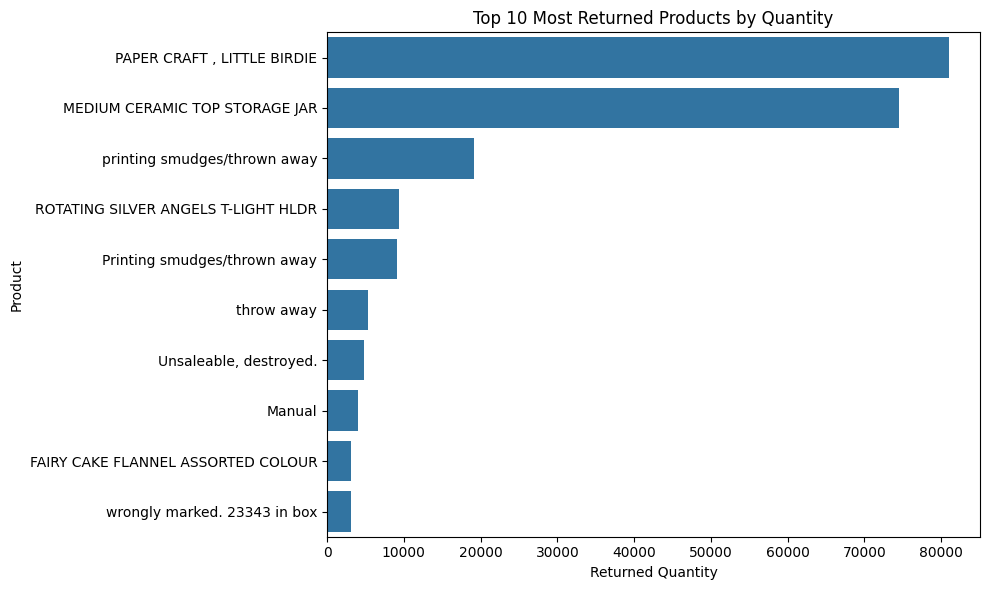

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 returned products by quantity
top_10_returns = top_returned_products.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_returns,
    x="Returned_Quantity",
    y="Description"
)

plt.title("Top 10 Most Returned Products by Quantity")
plt.xlabel("Returned Quantity")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

- The returns and cancellations analysis identified 3,836 cancelled invoices and 9,288 cancelled or returned product rows. 
- Total return value amounted to £896,812.49, representing 8.41% of total positive sales revenue. This shows that cancellations and returns had a meaningful impact on overall revenue. 
- Product-level analysis revealed that some of the largest returned quantities were linked to unusual records such as damaged, unsaleable, or wrongly marked items, suggesting internal stock adjustments rather than standard customer returns. 
- In terms of financial impact, several high-value return records were non-product items such as AMAZON FEE, Manual, POSTAGE, CRUK Commission, and Bank Charges. Therefore, future analysis should separate genuine customer product returns from operational adjustments and fees. 
- Among actual products, items such as PAPER CRAFT, LITTLE BIRDIE, MEDIUM CERAMIC TOP STORAGE JAR, REGENCY CAKESTAND 3 TIER, and WHITE HANGING HEART T-LIGHT HOLDER were notable contributors to return-related revenue loss.

# Exporting for SQL

In [80]:
# Exporting cleaned datasets for MySQL import

import pandas as pd

# 1. Original full dataset
df_raw = df.copy()
#--------------------------------------------------------------

# 2. Cleaned sales dataset
df_final = df_clean2.copy()

# Make sure correct data types are used
df_final["InvoiceDate"] = pd.to_datetime(df_final["InvoiceDate"], errors="coerce")
df_final["Quantity"] = pd.to_numeric(df_final["Quantity"], errors="coerce")
df_final["UnitPrice"] = pd.to_numeric(df_final["UnitPrice"], errors="coerce")

# Create Sales column
df_final["Sales"] = df_final["Quantity"] * df_final["UnitPrice"]
#--------------------------------------------------------------

# 3. Customer dataset
df_customer = df_final.dropna(subset=["CustomerID"]).copy()

# Convert CustomerID to string
df_customer["CustomerID"] = df_customer["CustomerID"].astype(int).astype(str)
#--------------------------------------------------------------

# 4. Returns / cancellations dataset

df_raw["InvoiceNo"] = df_raw["InvoiceNo"].astype(str)
df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"], errors="coerce")
df_raw["Quantity"] = pd.to_numeric(df_raw["Quantity"], errors="coerce")
df_raw["UnitPrice"] = pd.to_numeric(df_raw["UnitPrice"], errors="coerce")

df_returns = df_raw[
    (df_raw["Quantity"] < 0) |
    (df_raw["InvoiceNo"].str.startswith("C"))
].copy()

# Calculate return value as positive value
df_returns["ReturnValue"] = abs(df_returns["Quantity"] * df_returns["UnitPrice"])
#--------------------------------------------------------------

# 5. Export datasets for MySQL

df_final.to_csv("ecommerce_clean_sales.csv", index=False)
df_customer.to_csv("ecommerce_customers.csv", index=False)
df_returns.to_csv("ecommerce_returns.csv", index=False)
#--------------------------------------------------------------
# 6. Check exported dataset sizes

print("Clean sales dataset:", df_final.shape)
print("Customer dataset:", df_customer.shape)
print("Returns dataset:", df_returns.shape)

/var/folders/q5/5vwr4ldd30vgm4b8qpnrkcym0000gn/T/ipykernel_1530/2406828410.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final["InvoiceDate"] = pd.to_datetime(df_final["InvoiceDate"], errors="coerce")
/var/folders/q5/5vwr4ldd30vgm4b8qpnrkcym0000gn/T/ipykernel_1530/2406828410.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw["InvoiceDate"] = pd.to_datetime(df_raw["InvoiceDate"], errors="coerce")


Clean sales dataset: (527946, 9)
Customer dataset: (396483, 9)
Returns dataset: (10624, 9)
